# Lab 4
### Pixel Brightness Transformation


In [12]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
from skimage.exposure import histogram
from matplotlib.pyplot import bar

%matplotlib inline

# Helper functions from commonfunctions.py
def show_images(images,titles=None):
    n_ims = len(images)
    if titles is None: titles = ['(%d)' % i for i in range(1,n_ims + 1)]
    fig = plt.figure()
    n = 1
    for image,title in zip(images,titles):
        a = fig.add_subplot(1,n_ims,n)
        if image.ndim == 2: 
            plt.gray()
        plt.imshow(image)
        a.set_title(title)
        plt.axis('off')
        n += 1
    fig.set_size_inches(np.array(fig.get_size_inches()) * n_ims)
    plt.show()

def showHist(img):
    plt.figure()
    imgHist = histogram(img, nbins=256)
    bar(imgHist[1].astype(np.uint8), imgHist[0], width=0.8, align='center')
    plt.title('Histogram')
    plt.show()

## Experiment 1: Negative Transformation
Equation: $s = 255 - r$

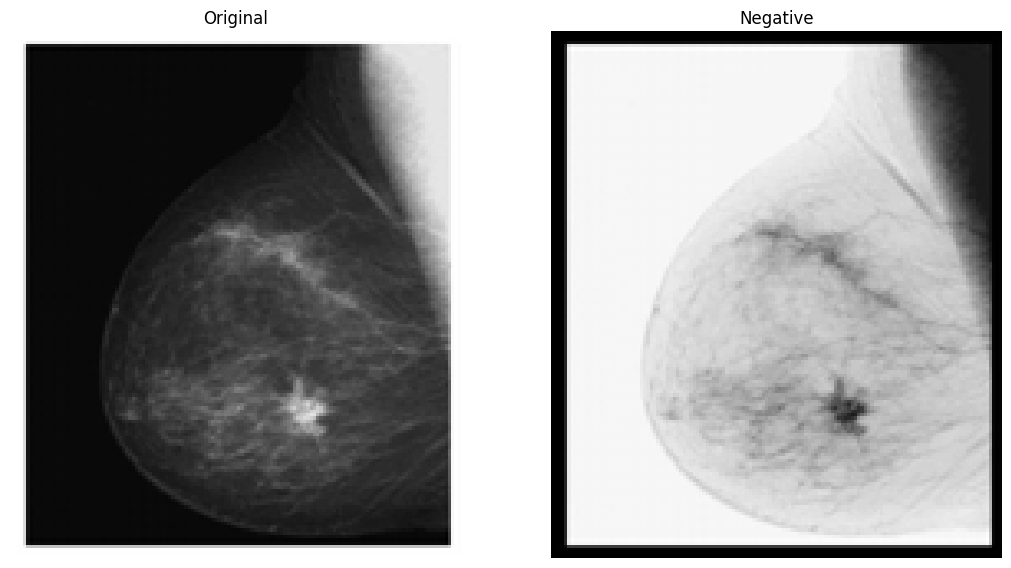

In [13]:
def Negative(image):
    neg_image = 255 - image
    return neg_image

img1 = io.imread('imgs/Picture1.png', as_gray=True)
if img1.dtype != np.uint8:
    img1 = (img1 * 255).astype(np.uint8)

img1_neg = Negative(img1)

show_images([img1, img1_neg], ['Original', 'Negative'])

## Experiment 2: Contrast Enhancement
Stretch gray levels [0, 100] to [50, 200], leave others unchanged.
Equation for $0 \le r \le 100$: $s = 50 + 1.5r$.

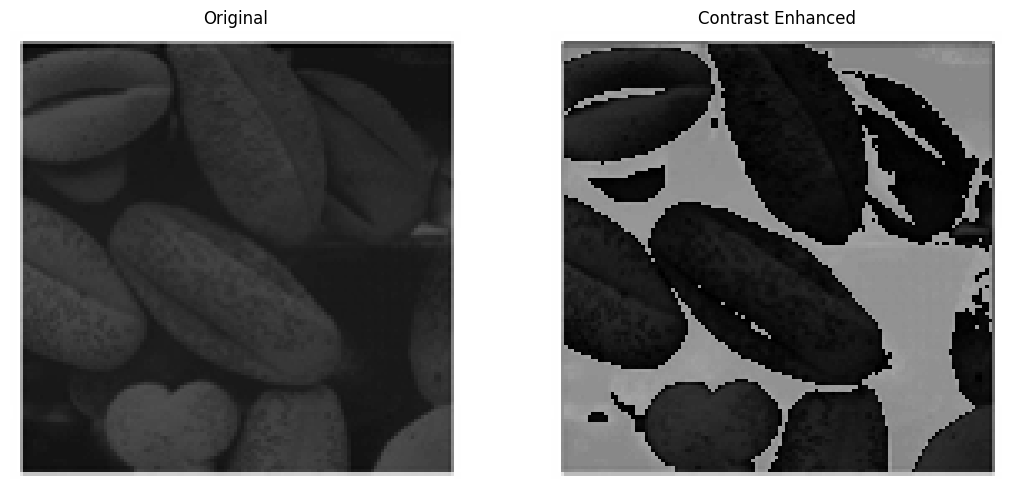

In [20]:
def Contrast_enhancement(image):
    img_out = image.copy().astype(float)
    
    mask = image <= 100
    
    img_out[mask] = 50 + 1.5 * image[mask]
    
    return np.clip(img_out, 0, 255).astype(np.uint8)

img2 = io.imread('imgs/Picture2.png', as_gray=True)
if img2.dtype != np.uint8:
    img2 = (img2 * 255).astype(np.uint8)

img2_enhanced = Contrast_enhancement(img2)

show_images([img2, img2_enhanced], ['Original', 'Contrast Enhanced'])

## Experiment 3: Gamma Correction
Equation: $s = c \cdot r^\gamma$. Input pixel values are normalized to [0, 1] before applying formula.

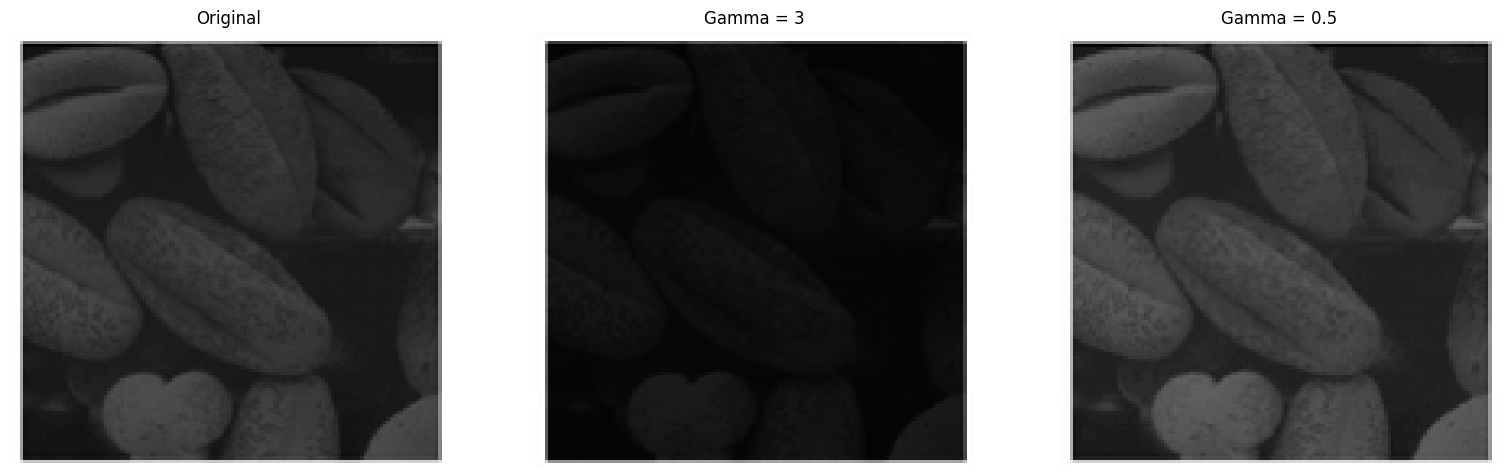

In [15]:
def Gamma_Correction(image, c, gamma):
    img_norm = image / 255.0
    
    s = c * (img_norm ** gamma)
    
    img_out = np.clip(s * 255.0, 0, 255).astype(np.uint8)
    return img_out

img_g3 = Gamma_Correction(img2, 1, 3)

img_g05 = Gamma_Correction(img2, 1, 0.5)

show_images([img2, img_g3, img_g05], 
            ['Original', 'Gamma = 3', 'Gamma = 0.5'])


**Effect of decreasing gamma:** Decreasing gamma below 1 expands the dark range and compresses the bright range, making the image appear brighter and enhancing details in darker regions.

## Experiment 4: Histogram Equalization

--- Processing Pout Image ---


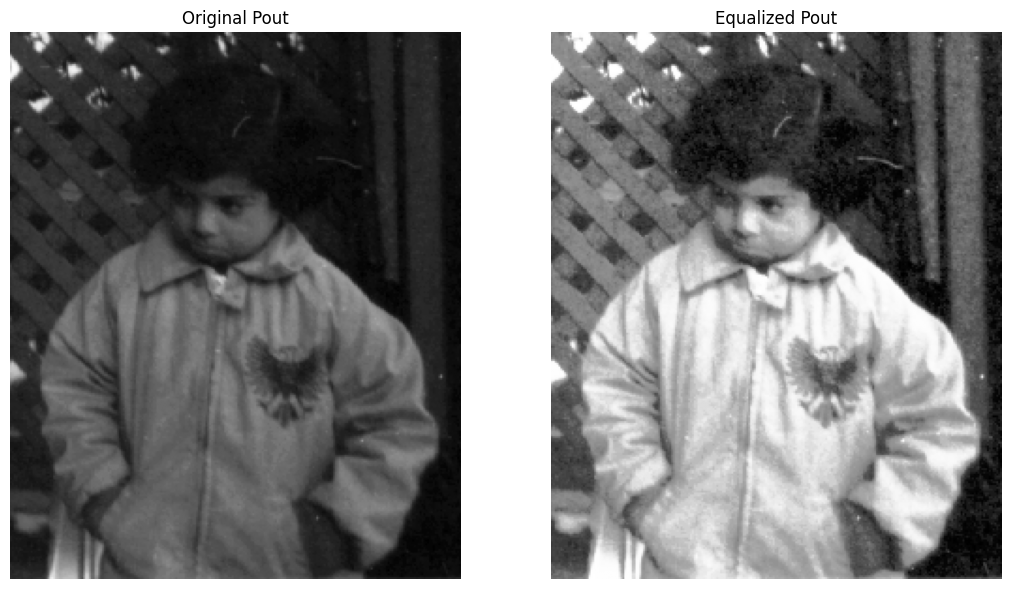

Original Pout Histogram:


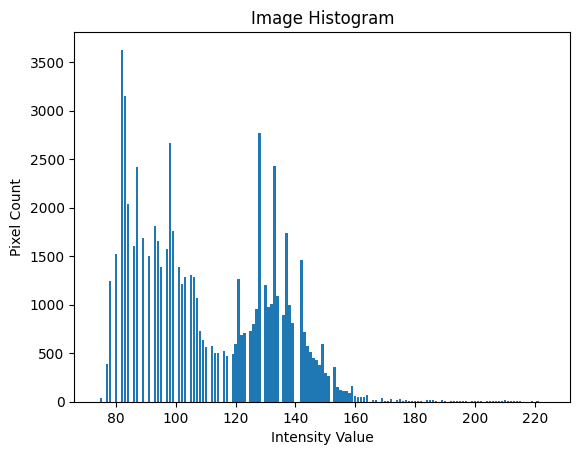

Equalized Pout Histogram:


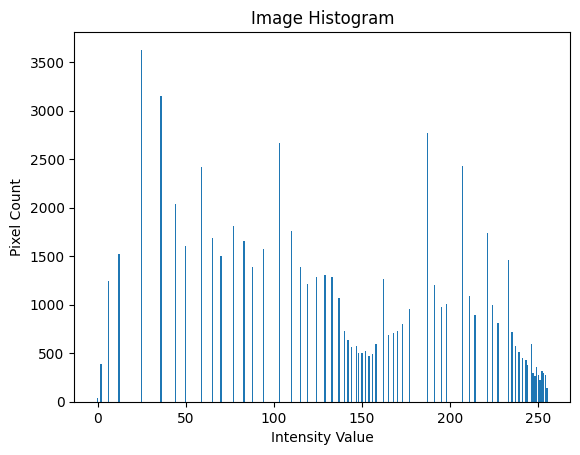


--- Processing Tire Image ---


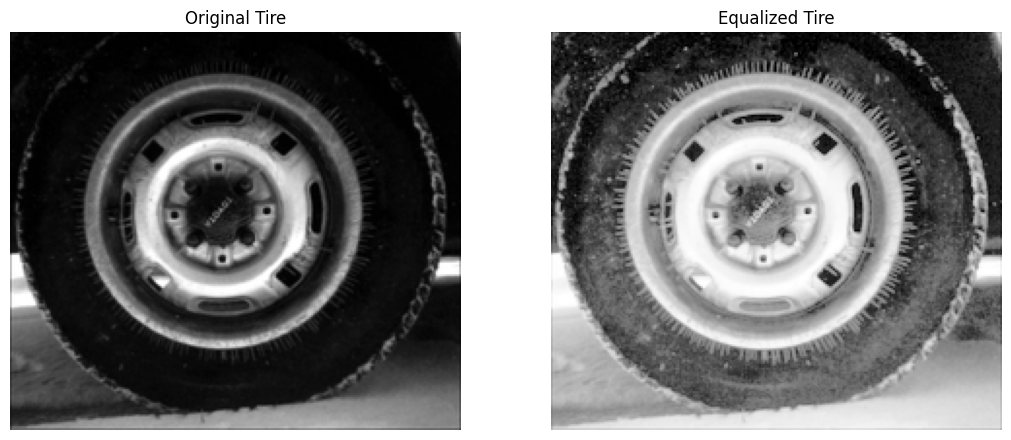

Original Tire Histogram:


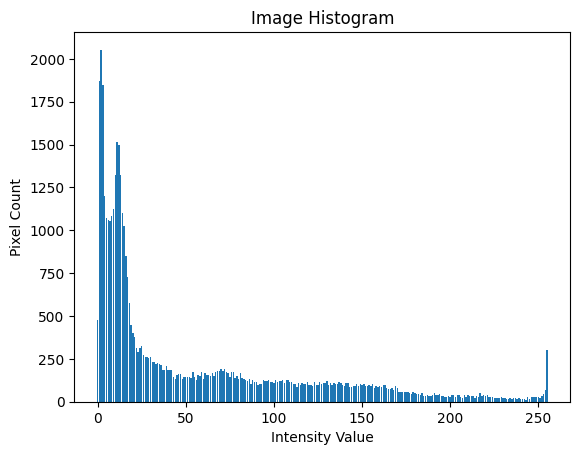

Equalized Tire Histogram:


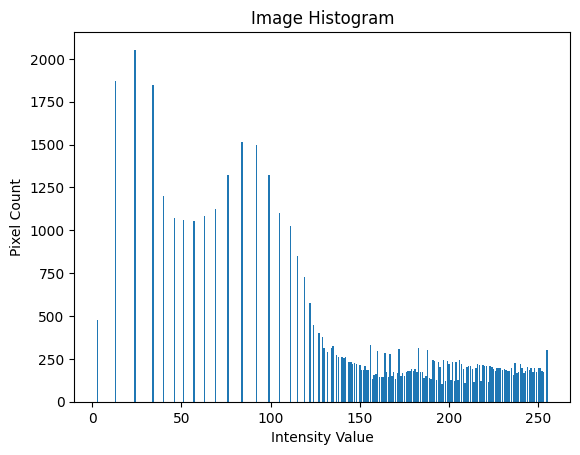

In [23]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
from skimage.exposure import histogram
from matplotlib.pyplot import bar

# --- Helper Functions (to make the script self-contained) ---

def show_images(images, titles=None):
    """Displays a list of images in a single row."""
    n_ims = len(images)
    if titles is None:
        titles = ['(%d)' % i for i in range(1, n_ims + 1)]
    fig = plt.figure()
    n = 1
    for image, title in zip(images, titles):
        a = fig.add_subplot(1, n_ims, n)
        if image.ndim == 2:
            plt.gray()
        plt.imshow(image)
        a.set_title(title)
        plt.axis('off')
        n += 1
    fig.set_size_inches(np.array(fig.get_size_inches()) * n_ims)
    plt.show()

def showHist(img):
    """Displays the histogram of an image."""
    plt.figure()
    # Calculate histogram using skimage
    hist_values, bins = histogram(img, nbins=256)
    # Plot the histogram as a bar chart
    plt.bar(bins.astype(np.uint8), hist_values, width=0.8, align='center')
    plt.title('Image Histogram')
    plt.xlabel('Intensity Value')
    plt.ylabel('Pixel Count')
    plt.show()

# --- Vectorized Histogram Equalization (Based on Lab Formula) ---

def equalize_histogram_vectorized(image):
    """
    Performs histogram equalization using NumPy vectorization,
    directly implementing the formula from the lab instructions.
    """
    N, M = image.shape
    total_pixels = N * M
    G = 256  # Number of gray levels

    # 1. Calculate the histogram (H)
    hist = np.histogram(image.flatten(), bins=G, range=[0, G])[0]

    # 2. Calculate the cumulative histogram (H_c), also known as CDF
    cdf = hist.cumsum()

    # 3. Calculate the mapping function (T) using the formula
    # q = round(((G - 1) * H_c[p]) / (N * M))
    mapping_table = np.round(((G - 1) * cdf) / total_pixels)

    mapping_table = mapping_table.astype(np.uint8)

    equalized_image = mapping_table[image]

    return equalized_image
    
img_pout = io.imread('imgs/pout.tif')
img_tire = io.imread('imgs/tire.tif')

print("--- Processing Pout Image ---")
img_pout_eq = equalize_histogram_vectorized(img_pout)
show_images([img_pout, img_pout_eq], ['Original Pout', 'Equalized Pout'])
print("Original Pout Histogram:")
showHist(img_pout)
print("Equalized Pout Histogram:")
showHist(img_pout_eq)

print("\n--- Processing Tire Image ---")
img_tire_eq = equalize_histogram_vectorized(img_tire)
show_images([img_tire, img_tire_eq], ['Original Tire', 'Equalized Tire'])
print("Original Tire Histogram:")
showHist(img_tire)
print("Equalized Tire Histogram:")
showHist(img_tire_eq)

## Extra Task: Color Correction (White Balance)
To eliminate the blue cast, we apply the Gray World assumption, which scales the color channels so that the average color of the entire image is gray.

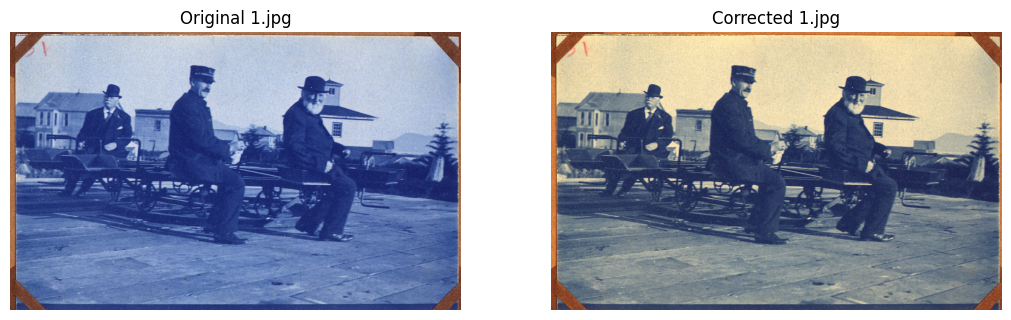

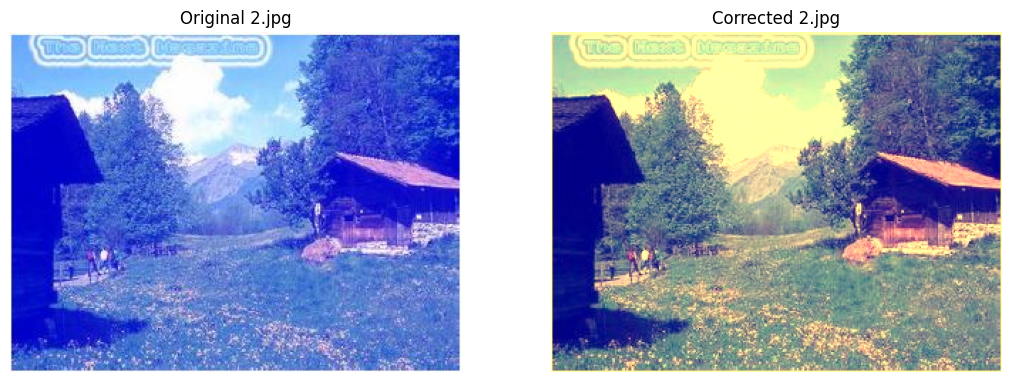

In [25]:
# Reference: https://acorn.stanford.edu/psych221/projects/2010/JasonSu/grayworld.html

def white_balance_gray_world(image):
    img_float = image.astype(float)
    
    avg_r = np.mean(img_float[:,:,0])
    avg_g = np.mean(img_float[:,:,1])
    avg_b = np.mean(img_float[:,:,2])
    
    avg_gray = (avg_r + avg_g + avg_b) / 3.0
    
    scale_r = avg_gray / avg_r
    scale_g = avg_gray / avg_g
    scale_b = avg_gray / avg_b
    
    # Apply the scaling factors
    img_float[:,:,0] *= scale_r
    img_float[:,:,1] *= scale_g
    img_float[:,:,2] *= scale_b
    
    return np.clip(img_float, 0, 255).astype(np.uint8)

path = '../Lab 4 extra task images/'
files = ['1.jpg', '2.jpg']

for f in files:
    img = io.imread(path + f)
    img_corrected = white_balance_gray_world(img)
    show_images([img, img_corrected], [f'Original {f}', f'Corrected {f}'])